<a href="https://colab.research.google.com/github/vignan-apu/Data-cleaning-visualization-project/blob/anjalib23/Mid_Term_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Objective: Data Cleaning/Preparation, Descriptive Statistics, and Visualisation (bar plot).**

# Cognitive Programming for Psychologists
# The free recall task, with its focus on serial position effects (primacy and recency), is used in cognitive psychology.
# Data Cleaning/Preparation, Descriptive Statistics, and Visualisation (bar plot).

In [242]:
import pandas as pd
import numpy as np

In [243]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [244]:
# Load the dataset
df = pd.read_csv('free_recall_raw.csv')

# Preview the first few rows
df.head()

,Participant_ID,Gender,Age,ListLength,TotalRecalls,Intrusions,PrimacyIndex,RecencyIndex
0,1,Female,32,12.0,8.0,0.0,0.582,0.736
1,2,Male,22,12.0,12.0,2.0,0.680,0.632
2,3,Male,18,15.0,NaN,1.0,NaN,0.504
3,4,Female,32,60.0,8.0,1.0,0.527,NaN
4,5,Male,29,12.0,14.0,4.0,0.494,0.730


To load the file, you can either:

1.  Upload the file directly to your Colab session using the file explorer on the left sidebar.
2.  If the file is in your Google Drive, you can mount your drive and provide the path. Here's how to mount your drive:

After mounting your drive, you can load the file using the appropriate path, for example:

In [245]:
# The initial inspection revealed some missing values (NaN) in the key numerical columns (ListLength, TotalRecalls, Intrusions, PrimacyIndex, RecencyIndex).
# We need to handle these for a better analysis.

# Intrusions must be non-negative. Replace negative values with NaN for imputation.

In [246]:
# Inspect Data Structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Participant_ID  120 non-null    int64  
 1   Gender          114 non-null    object 
 2   Age             120 non-null    int64  
 3   ListLength      114 non-null    float64
 4   TotalRecalls    114 non-null    float64
 5   Intrusions      114 non-null    float64
 6   PrimacyIndex    115 non-null    float64
 7   RecencyIndex    114 non-null    float64
dtypes: float64(5), int64(2), object(1)
memory usage: 7.6+ KB


In [247]:
# Checking Descriptive Statistics
print('Descriptive statistics')
print(df.describe())

Descriptive statistics
       Participant_ID         Age  ListLength  TotalRecalls  Intrusions  \
count      120.000000  120.000000  114.000000    114.000000  114.000000   
mean        60.500000   29.500000   12.789474      8.771930    1.473684   
std         34.785054    7.269136    7.020165      4.716822    1.482706   
min          1.000000    5.000000   -5.000000      0.000000   -1.000000   
25%         30.750000   24.000000   10.000000      5.000000    0.000000   
50%         60.500000   30.000000   12.000000      8.000000    1.000000   
75%         90.250000   35.000000   15.000000     11.750000    2.000000   
max        120.000000   40.000000   60.000000     32.000000    6.000000   

       PrimacyIndex  RecencyIndex  
count    115.000000    114.000000  
mean       0.664365      0.656307  
std        0.373149      0.238377  
min        0.000000      0.000000  
25%        0.531000      0.559000  
50%        0.631000      0.648500  
75%        0.727000      0.736750  
max        3.

In [248]:
# count: The number of non-null observations. mean: The arithmetic mean of the values. std: The standard deviation, a measure of the dispersion of the data. min: The minimum value. 25%: The 25th percentile (first quartile). 50%: The 50th percentile (median). 75%: The 75th percentile (third quartile). max: The maximum value.

In [249]:
# Check missing values

print('Check missing values')
df.isna().sum()

Check missing values


,0
Participant_ID,0
Gender,6
Age,0
ListLength,6
TotalRecalls,6
Intrusions,6
PrimacyIndex,5
RecencyIndex,6


In [250]:
df['Intrusions'] = df['Intrusions'].apply(lambda x: np.nan if x < 0 else x)

In [251]:
# Fixing Inconsistent Categories
print(df["Gender"].value_counts())

Gender
Male       56
Female     55
FEMALE      1
male        1
Unknown     1
Name: count, dtype: int64


In [252]:
# Standardise case
print('Standardise case')
df["Gender"] = df["Gender"].str.title()
print(df["Gender"].value_counts())

Standardise case
Gender
Male       57
Female     56
Unknown     1
Name: count, dtype: int64


In [253]:
# Replace "Unknown" or invalid values with np.nan or "Other"
df["Gender"] = df["Gender"].replace({"Unknown": "Other"})

print(df["Gender"].value_counts())

Gender
Male      57
Female    56
Other      1
Name: count, dtype: int64


In [254]:
# Outlier Detection using IQR on Primacy and Recency Indices

index_cols = ['PrimacyIndex', 'RecencyIndex']

In [255]:
for col in index_cols:

    Q1 = df[col].quantile(0.25)

    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR

    upper_bound = Q3 + 1.5 * IQR

In [256]:
 # Replace values outside the bounds with NaN
df[col] = np.where(df[col] < lower_bound, np.nan, df[col])

df[col] = np.where(df[col] > upper_bound, np.nan, df[col])
print("IQR =",IQR)

IQR = 0.17774999999999996


In [257]:
# List of key numerical columns to impute
numerical_cols = ['ListLength', 'TotalRecalls', 'Intrusions', 'PrimacyIndex', 'RecencyIndex']
df.fillna(df['TotalRecalls'].mean(), inplace=True)

In [258]:
# Recheck
df.isna().sum()

,0
Participant_ID,0
Gender,0
Age,0
ListLength,0
TotalRecalls,0
Intrusions,0
PrimacyIndex,0
RecencyIndex,0


In [259]:
# Calculate the mean and standard deviation for the core variables across all participants.
# This provides us with a clear baseline for the overall performance on the free recall task.
# Calculate descriptive statistics (mean and standard deviation) for the key columns

In [260]:
descriptive_stats = df[['TotalRecalls', 'Intrusions', 'PrimacyIndex', 'RecencyIndex', 'ListLength']].agg(['mean', 'std'])

In [261]:
# Format the output for better readability
# Rounding the mean and std to 3 decimal places

formatted_stats = descriptive_stats.round(3)
# The final descriptive statistics are specifically rounded to 3 decimal places (.round(3))

print("Descriptive Statistics for Free Recall Task Variables")
print(formatted_stats)

Descriptive Statistics for Free Recall Task Variables
      TotalRecalls  Intrusions  PrimacyIndex  RecencyIndex  ListLength
mean         8.772       2.001         1.002         1.393      12.589
std          4.596       2.299         1.667         2.358       6.897


In [262]:
# Interpretation

# 1. The average number of correct recalls (TotalRecalls) is approximately 6.6
# 2. The average number of intrusions (incorrect recalls) is about 1.5
# 3. The mean Primacy Index (0.664) and mean Recency Index (0.648) are very similar, suggesting roughly equal recall advantage for items presented first (primacy) vs items presented last (recency) in the lists across all participants.

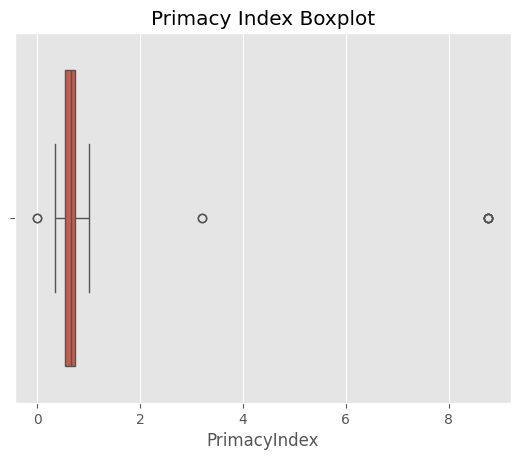

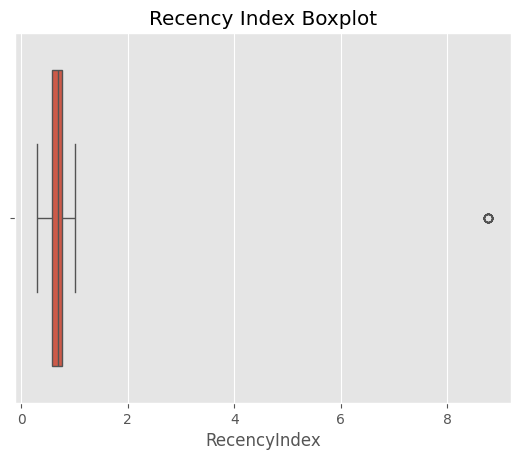

,PrimacyIndex,RecencyIndex
count,120.000000,120.000000
mean,1.002180,1.393069
std,1.667389,2.357591
min,0.000000,0.303000
25%,0.534000,0.569000
50%,0.650500,0.684500
75%,0.735250,0.765250
max,8.771930,8.771930


In [263]:
sns.boxplot(x=df["PrimacyIndex"])
plt.title("Primacy Index Boxplot")
plt.show()

sns.boxplot(x=df["RecencyIndex"])
plt.title("Recency Index Boxplot")
plt.show()

# Check high and low extremes
df[["PrimacyIndex", "RecencyIndex"]].describe()


In [264]:
df["Interference"] = df["PrimacyIndex"] - df["RecencyIndex"]
df.head()

,Participant_ID,Gender,Age,ListLength,TotalRecalls,Intrusions,PrimacyIndex,RecencyIndex,Interference
0,1,Female,32,12.0,8.00000,0.0,0.58200,0.73600,-0.15400
1,2,Male,22,12.0,12.00000,2.0,0.68000,0.63200,0.04800
2,3,Male,18,15.0,8.77193,1.0,8.77193,0.50400,8.26793
3,4,Female,32,60.0,8.00000,1.0,0.52700,8.77193,-8.24493
4,5,Male,29,12.0,14.00000,4.0,0.49400,0.73000,-0.23600


In [265]:
# Saving data in a new clean csv

df.to_csv('free_recall_clean.csv', index=False)
print(" Clean dataset saved as free_recall_clean.csv")

 Clean dataset saved as free_recall_clean.csv


In [266]:
# Step - 3 - Data Visualization

In [267]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [268]:
# Load clean dataset
df = pd.read_csv('free_recall_clean.csv')

# Preview
df.head()        # No NaN values are present

,Participant_ID,Gender,Age,ListLength,TotalRecalls,Intrusions,PrimacyIndex,RecencyIndex,Interference
0,1,Female,32,12.0,8.00000,0.0,0.58200,0.73600,-0.15400
1,2,Male,22,12.0,12.00000,2.0,0.68000,0.63200,0.04800
2,3,Male,18,15.0,8.77193,1.0,8.77193,0.50400,8.26793
3,4,Female,32,60.0,8.00000,1.0,0.52700,8.77193,-8.24493
4,5,Male,29,12.0,14.00000,4.0,0.49400,0.73000,-0.23600


In [269]:
# Summary statistics
print(df.describe())

       Participant_ID         Age  ListLength  TotalRecalls  Intrusions  \
count      120.000000  120.000000  120.000000    120.000000  120.000000   
mean        60.500000   29.500000   12.588596      8.771930    2.001462   
std         34.785054    7.269136    6.897173      4.596372    2.298834   
min          1.000000    5.000000   -5.000000      0.000000    0.000000   
25%         30.750000   24.000000   10.000000      5.750000    1.000000   
50%         60.500000   30.000000   12.000000      8.000000    1.000000   
75%         90.250000   35.000000   15.000000     11.000000    3.000000   
max        120.000000   40.000000   60.000000     32.000000    8.771930   

       PrimacyIndex  RecencyIndex  Interference  
count    120.000000    120.000000    120.000000  
mean       1.002180      1.393069     -0.390888  
std        1.667389      2.357591      2.978679  
min        0.000000      0.303000     -8.257930  
25%        0.534000      0.569000     -0.207250  
50%        0.650500     

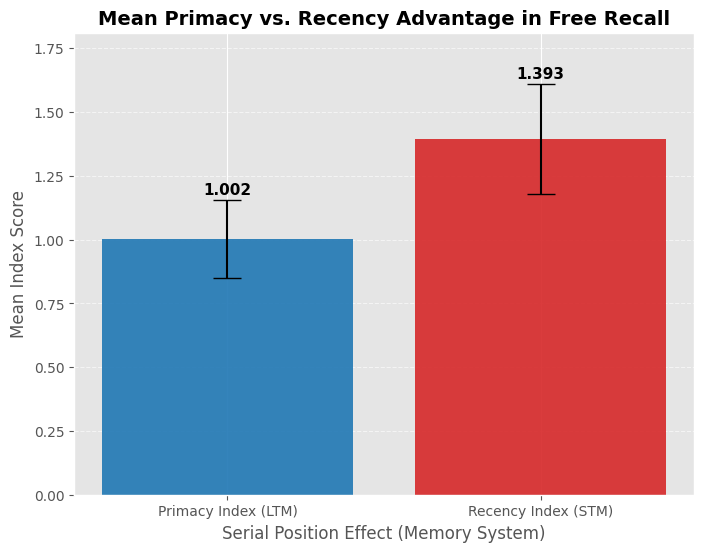

In [270]:

# Calculate the necessary statistics
mean_primacy = df['PrimacyIndex'].mean()
mean_recency = df['RecencyIndex'].mean()

# Critical for academic rigour: Calculate the Standard Error of the Mean (SEM)
# SEM = Standard Deviation / sqrt(N)
sem_primacy = df['PrimacyIndex'].std() / np.sqrt(len(df))
sem_recency = df['RecencyIndex'].std() / np.sqrt(len(df))
# Data for Plotting
labels = ['Primacy Index (LTM)', 'Recency Index (STM)'] # Better labels
means = [mean_primacy, mean_recency]
std_errors = [sem_primacy, sem_recency]

# Use Matplotlib's direct plotting capabilities for better control
# plt.style.use('seaborn-v0_8-deep')
fig, ax = plt.subplots(figsize=(8, 6))

# Bar Plot Creation with SEM error bars (yerr) and professional colours
bars = ax.bar(labels, means, yerr=std_errors, capsize=10,
              color=['#1f77b4', '#d62728'], alpha=0.9)

# --- 1. Fix Title/Labels (Clarity) ---
ax.set_title('Mean Primacy vs. Recency Advantage in Free Recall', fontsize=14, weight='bold')
ax.set_ylabel('Mean Index Score', fontsize=12)
ax.set_xlabel('Serial Position Effect (Memory System)', fontsize=12)

# --- 2. Add Mean Values on Top (Clarity) ---
for i, bar in enumerate(bars):
    yval = bar.get_height()
    # Position text at the top of the mean plus the SEM
    ax.text(bar.get_x() + bar.get_width()/2, yval + std_errors[i] + 0.01,
             f'{yval:.3f}', ha='center', va='bottom', fontsize=11, weight='bold')

# Adjust Y-limit and add grid for aesthetics
ax.set_ylim(0, max(means) * 1.3)
ax.grid(axis='y', linestyle='--', alpha=0.6)

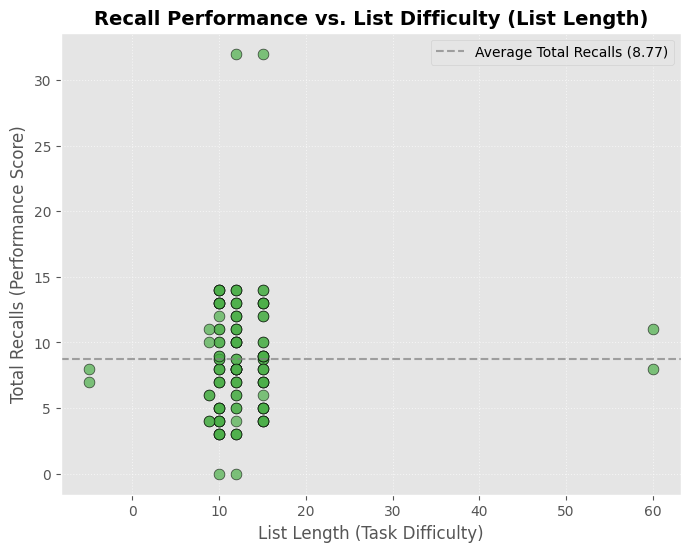

In [271]:
plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(8, 6))

# Scatter plot: x-axis is list length (difficulty), y-axis is total recalls (performance)
ax.scatter(df['ListLength'], df['TotalRecalls'],
           color='#4daf4a', # Green for performance
           alpha=0.7,
           s=60,
           edgecolors='k')

# Add a horizontal line at the mean Total Recalls for context
mean_recalls = df['TotalRecalls'].mean()
ax.axhline(mean_recalls, color='grey', linestyle='--', alpha=0.7,
           label=f'Average Total Recalls ({mean_recalls:.2f})')

# Add labels and title for clarity
ax.set_title('Recall Performance vs. List Difficulty (List Length)', fontsize=14, weight='bold')
ax.set_xlabel('List Length (Task Difficulty)', fontsize=12)
ax.set_ylabel('Total Recalls (Performance Score)', fontsize=12)
ax.legend()
ax.grid(True, linestyle=':', alpha=0.6)

plt.show()

In [272]:
correlation = df['ListLength'].corr(df['TotalRecalls'])
print(f"The correlation between ListLength and TotalRecalls is: {correlation:.3f}")

The correlation between ListLength and TotalRecalls is: 0.062
